# MDN feature sweep results

Fixed architecture (2×64, K=8). Gas surface density + one feature at a time.
Compares in-sample vs OOS NLL to diagnose overfitting from added features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
df = pd.read_csv("mdn_feature_sweep.csv")
with open("mdn_feature_sweep.curves.json") as f:
    curves = json.load(f)

feature_sets = df["features"].tolist()
galaxy_cols = [c.replace("oos_nll_", "") for c in df.columns if c.startswith("oos_nll_") and c != "oos_nll_mean"]
print(f"Feature sets: {feature_sets}")
print(f"Galaxies: {galaxy_cols}")
df

Feature sets: ['gas', 'gas+star', 'gas+rotcurve', 'gas+kappa', 'gas+dm', 'gas+kappa+dm']
Galaxies: ['MW', 'NGC300', 'ETG-vlM', 'ETG-lowM', 'ETG-medM', 'ETG-hiM']


,features,feature_indices,is_nll_MW,is_r2_MW,oos_nll_MW,oos_r2_MW,is_nll_NGC300,is_r2_NGC300,oos_nll_NGC300,oos_r2_NGC300,...,oos_r2_ETG-medM,is_nll_ETG-hiM,is_r2_ETG-hiM,oos_nll_ETG-hiM,oos_r2_ETG-hiM,is_nll_mean,is_r2_mean,oos_nll_mean,oos_r2_mean,nll_gap
0,gas,[0],1.336107,0.437847,1.775555,0.073631,1.279145,0.505798,1.855136,0.027318,...,0.594143,1.391021,0.360494,1.368453,0.393527,1.355491,0.404842,1.545083,0.288125,0.189592
1,gas+star,"[0, 1]",1.246326,0.481328,1.771529,0.080064,1.250679,0.532803,1.910940,-0.016774,...,0.672389,1.259750,0.423089,1.968775,0.383456,1.273446,0.450669,1.635728,0.294994,0.362282
2,gas+rotcurve,"[0, 2]",1.239196,0.478331,2.073673,0.044379,1.239515,0.502248,2.183375,-0.309850,...,0.420748,1.307576,0.394343,1.524696,0.392081,1.307362,0.431416,1.694371,0.176201,0.387009
3,gas+kappa,"[0, 3]",1.225183,0.486783,1.777938,0.057293,1.167941,0.545602,1.629924,0.049116,...,0.795202,1.330639,0.419728,1.413181,0.445967,1.271198,0.456779,1.461416,0.338346,0.190218
4,gas+dm,"[0, 4]",1.298130,0.483816,1.964177,0.050316,1.207554,0.543170,1.705941,0.040204,...,0.759878,1.389174,0.386516,1.413757,0.445286,1.301173,0.446900,1.524916,0.335288,0.223743
5,gas+kappa+dm,"[0, 3, 4]",1.267879,0.435752,2.016205,-0.124504,1.233833,0.540006,1.756811,0.052194,...,0.738115,1.315430,0.400080,1.390287,0.445571,1.273510,0.445374,1.515899,0.299806,0.242389


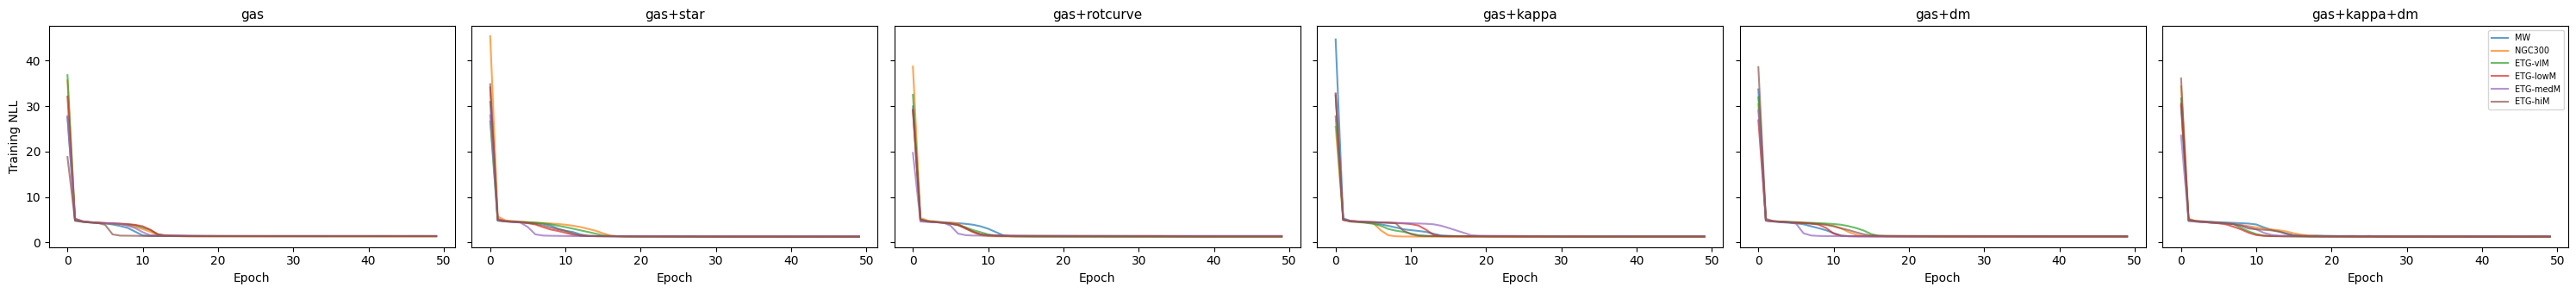

In [3]:
# Training curves: one subplot per feature set, colored by held-out galaxy
n_sets = len(curves)
fig, axes = plt.subplots(1, n_sets, figsize=(5 * n_sets, 3.5), sharey=True)

for idx, (feat_name, fold_curves) in enumerate(curves.items()):
    ax = axes[idx]
    for gal_name, losses in fold_curves.items():
        ax.plot(losses, alpha=0.7, label=gal_name)
    ax.set_title(feat_name, fontsize=11)
    ax.set_xlabel("Epoch")

axes[0].set_ylabel("Training NLL")
axes[-1].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()

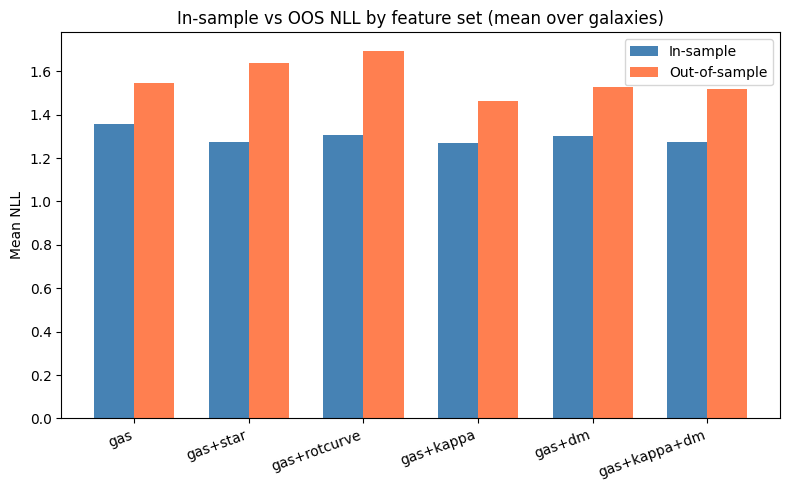

In [4]:
# Mean NLL bar chart: in-sample vs OOS
x = np.arange(len(feature_sets))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, df["is_nll_mean"], width, label="In-sample", color="steelblue")
ax.bar(x + width/2, df["oos_nll_mean"], width, label="Out-of-sample", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(feature_sets, rotation=20, ha="right")
ax.set_ylabel("Mean NLL")
ax.set_title("In-sample vs OOS NLL by feature set (mean over galaxies)")
ax.legend()

plt.tight_layout()
plt.show()

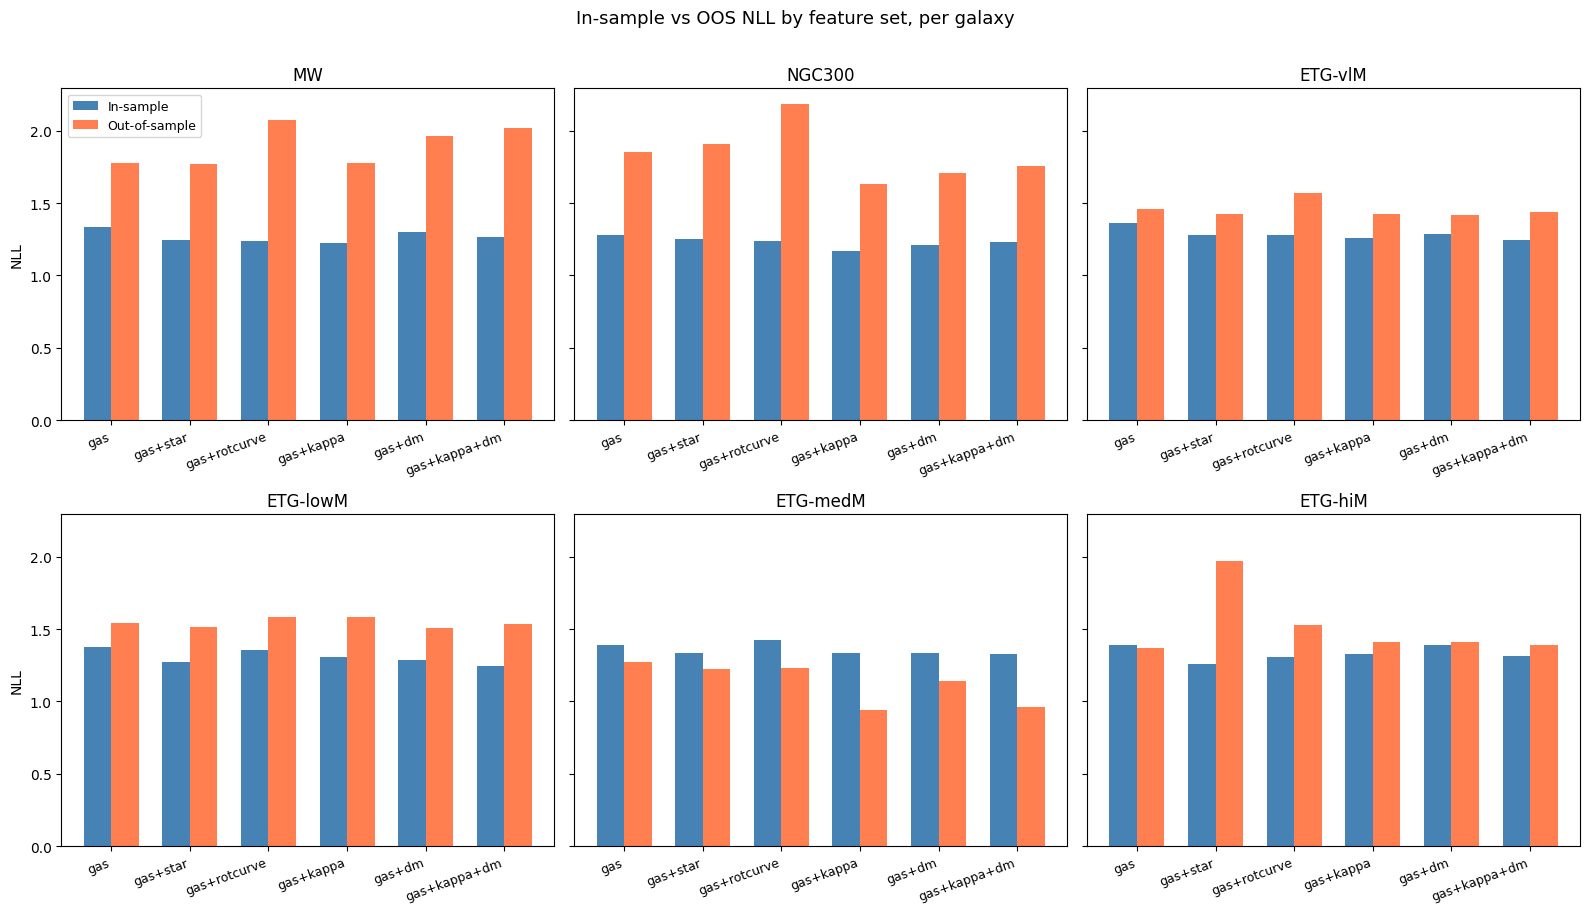

In [5]:
# Per-galaxy NLL bar charts: 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for idx, gal in enumerate(galaxy_cols):
    ax = axes[idx]
    is_vals = df[f"is_nll_{gal}"].values
    oos_vals = df[f"oos_nll_{gal}"].values

    ax.bar(x - width/2, is_vals, width, label="In-sample", color="steelblue")
    ax.bar(x + width/2, oos_vals, width, label="Out-of-sample", color="coral")

    ax.set_xticks(x)
    ax.set_xticklabels(feature_sets, rotation=20, ha="right", fontsize=9)
    ax.set_title(gal)

# Hide unused subplot if odd number of galaxies
for idx in range(len(galaxy_cols), len(axes)):
    axes[idx].set_visible(False)

axes[0].set_ylabel("NLL")
axes[3].set_ylabel("NLL")
axes[0].legend(fontsize=9)
fig.suptitle("In-sample vs OOS NLL by feature set, per galaxy", fontsize=13, y=1.01)

plt.tight_layout()
plt.show()